# Induction Motor Fault Diagnosis - Deep Learning Approach

## 1. Introduction
This notebook implements Deep Learning models (CNN and LSTM) for fault diagnosis.
Unlike ML models that rely on manual feature extraction, DL models learn features directly from the raw time-series data.

**Dataset**: Induction Motor Fault Data
**Models**: 1D Convolutional Neural Network (CNN), Long Short-Term Memory (LSTM)
**Objective**: Leverage temporal patterns in the signal for high-accuracy classification.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['lines.linewidth'] = 2.0

## 2. Data Loading and Preprocessing
We load the raw signals. For DL, we need to ensure the input shape is `(samples, time_steps, features)`.

In [2]:
# Define paths
BASE_PATH = r"../Induction_Motor_Fault_Data"
LABEL_PATH = os.path.join(BASE_PATH, "lable.csv")
DATA_PATH = os.path.join(BASE_PATH, "x1z", "x1.np")

# Load Data
print("Loading data...")
try:
    data_signals = joblib.load(DATA_PATH)
    labels_df = pd.read_csv(LABEL_PATH, header=None)
    
    # Align data
    min_len = min(len(data_signals), len(labels_df))
    X = data_signals[:min_len]

    # FIX: Downsample data to reduce memory usage (100k -> 5k)
    # Taking every 20th sample preserves the signal pattern while reducing size
    print(f"Original Data Shape: {np.array(X).shape}")
    X = np.array([x[::20] for x in X]) # Downsample by factor of 20
    print(f"Downsampled Data Shape: {X.shape}")
    y = labels_df.iloc[:min_len, 0].values # Class labels
 # Fixed: Changed col 2 to 0 based on data inspection
    
    print(f"Data Shape: {X.shape}")
    print(f"Labels Shape: {y.shape}")
    
except Exception as e:
    print(f"Error loading data: {e}")

Loading data...
Original Data Shape: (2617, 100000, 2)
Downsampled Data Shape: (2617, 5000, 2)
Data Shape: (2617, 5000, 2)
Labels Shape: (2617,)


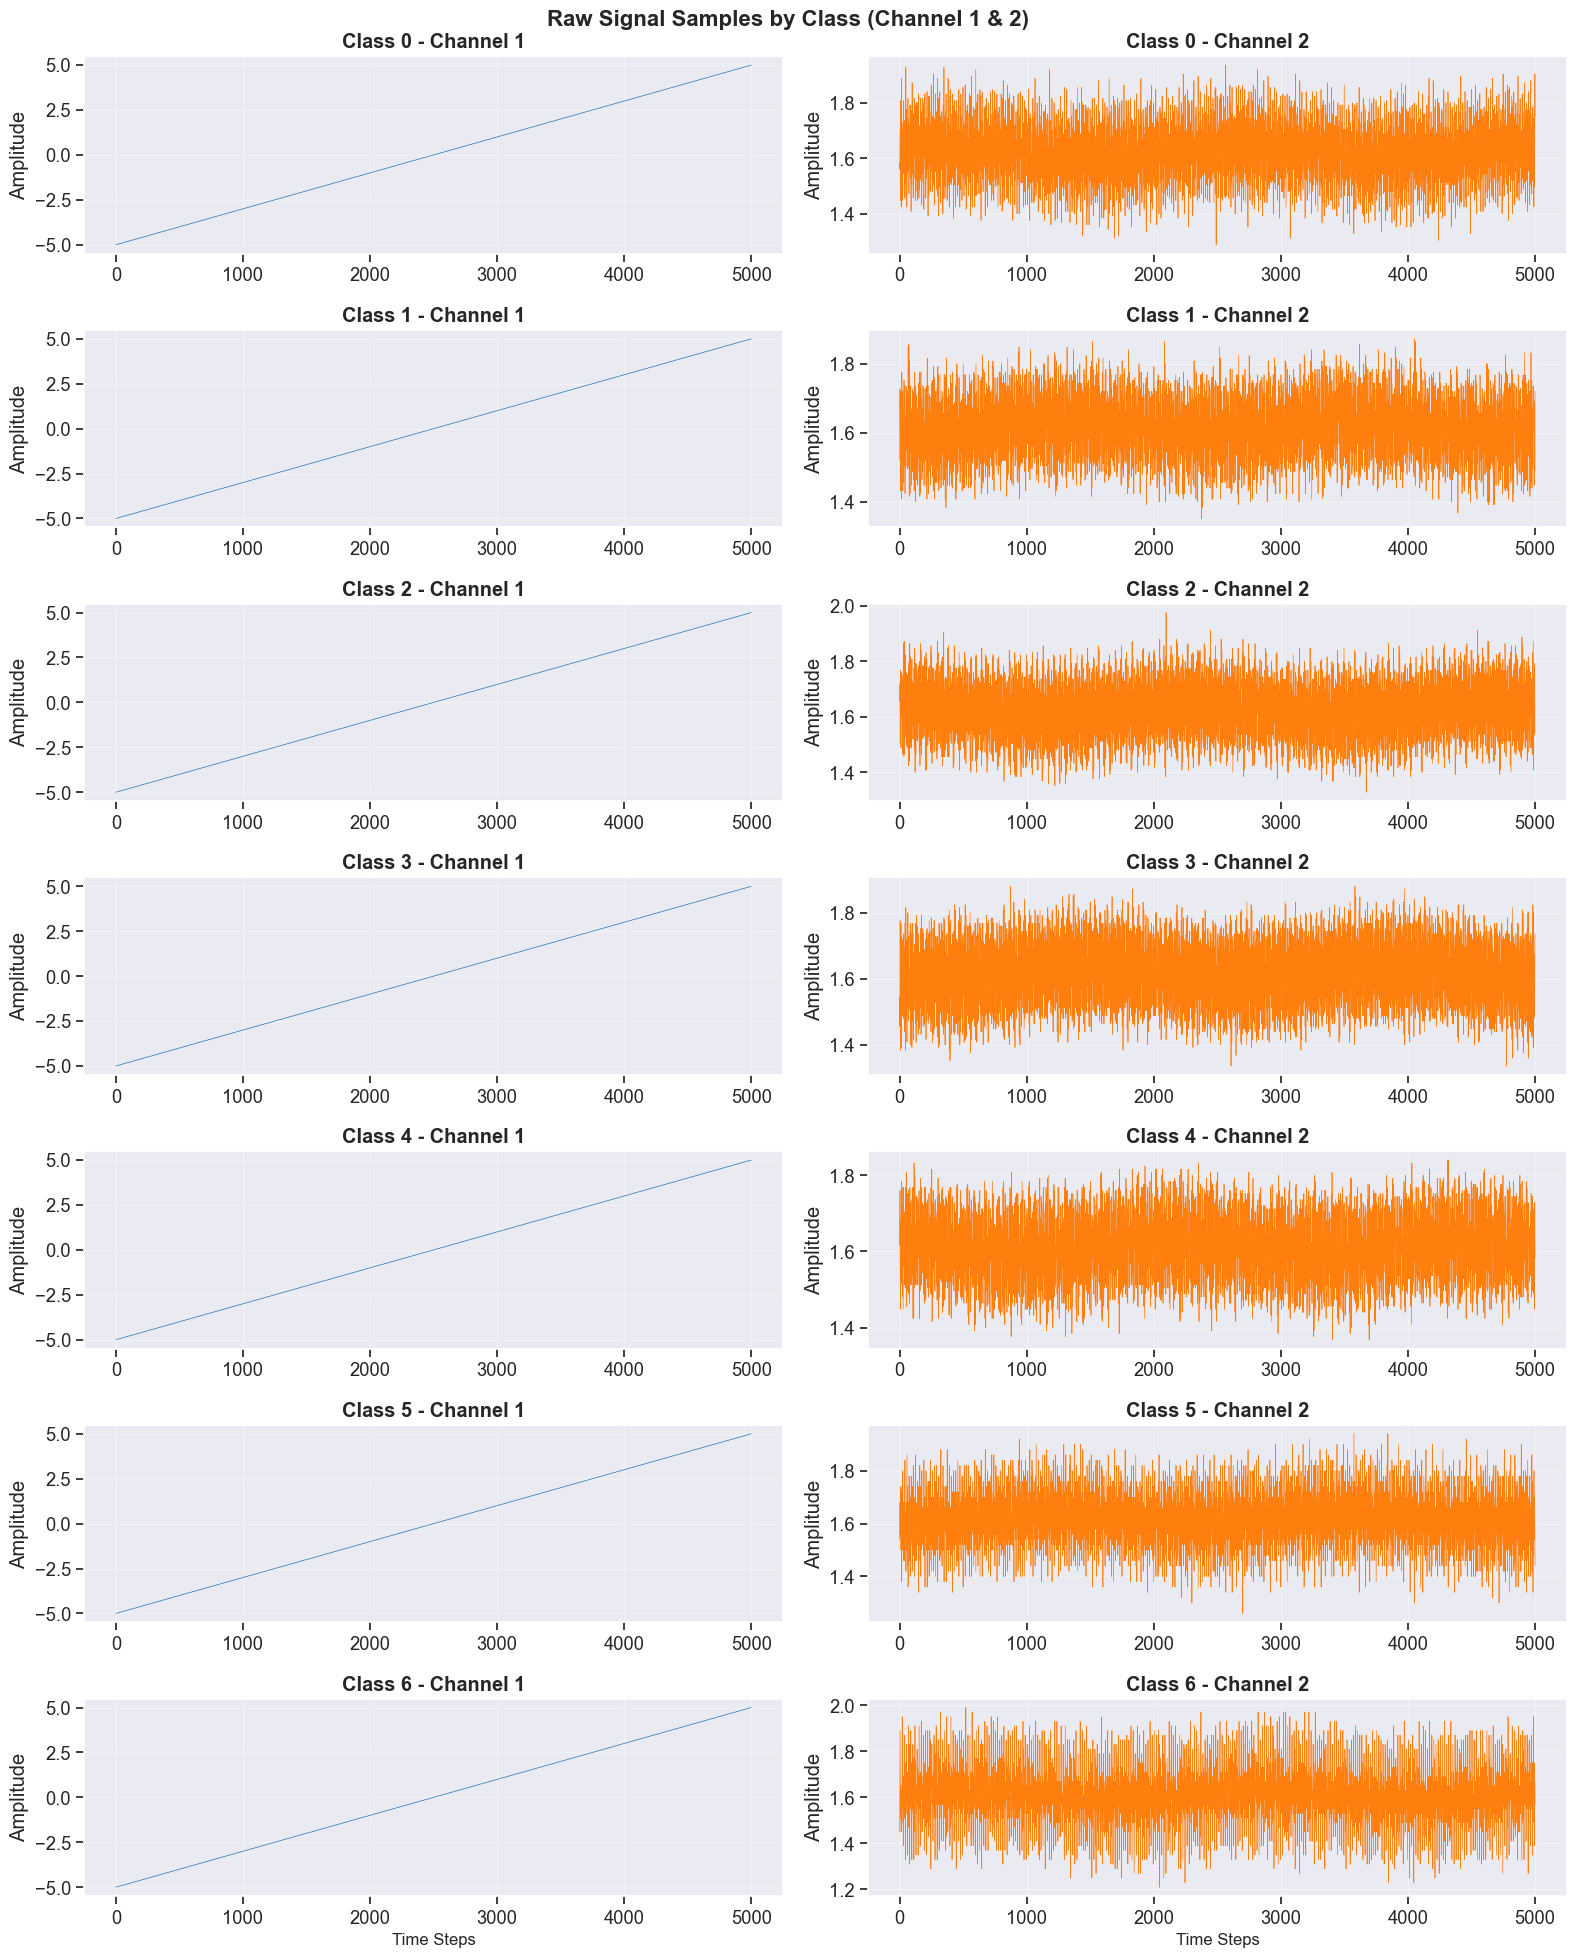

In [3]:
### Signal Visualization for Publication
import matplotlib.pyplot as plt
import numpy as np

# Plot sample signals from each class
fig, axes = plt.subplots(7, 2, figsize=(16, 20))
fig.suptitle('Raw Signal Samples by Class (Channel 1 & 2)', fontsize=16, fontweight='bold')

for class_idx in range(7):
    # Find first sample of this class
    class_samples = np.where(y == class_idx)[0]
    if len(class_samples) > 0:
        sample_idx = class_samples[0]
        signal = X[sample_idx]
        
        # Plot Channel 1
        axes[class_idx, 0].plot(signal[:, 0], linewidth=0.5, color='#1f77b4')
        axes[class_idx, 0].set_title(f'Class {class_idx} - Channel 1', fontweight='bold')
        axes[class_idx, 0].set_ylabel('Amplitude')
        axes[class_idx, 0].grid(alpha=0.3)
        
        # Plot Channel 2
        axes[class_idx, 1].plot(signal[:, 1], linewidth=0.5, color='#ff7f0e')
        axes[class_idx, 1].set_title(f'Class {class_idx} - Channel 2', fontweight='bold')
        axes[class_idx, 1].set_ylabel('Amplitude')
        axes[class_idx, 1].grid(alpha=0.3)

axes[-1, 0].set_xlabel('Time Steps', fontsize=12)
axes[-1, 1].set_xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()


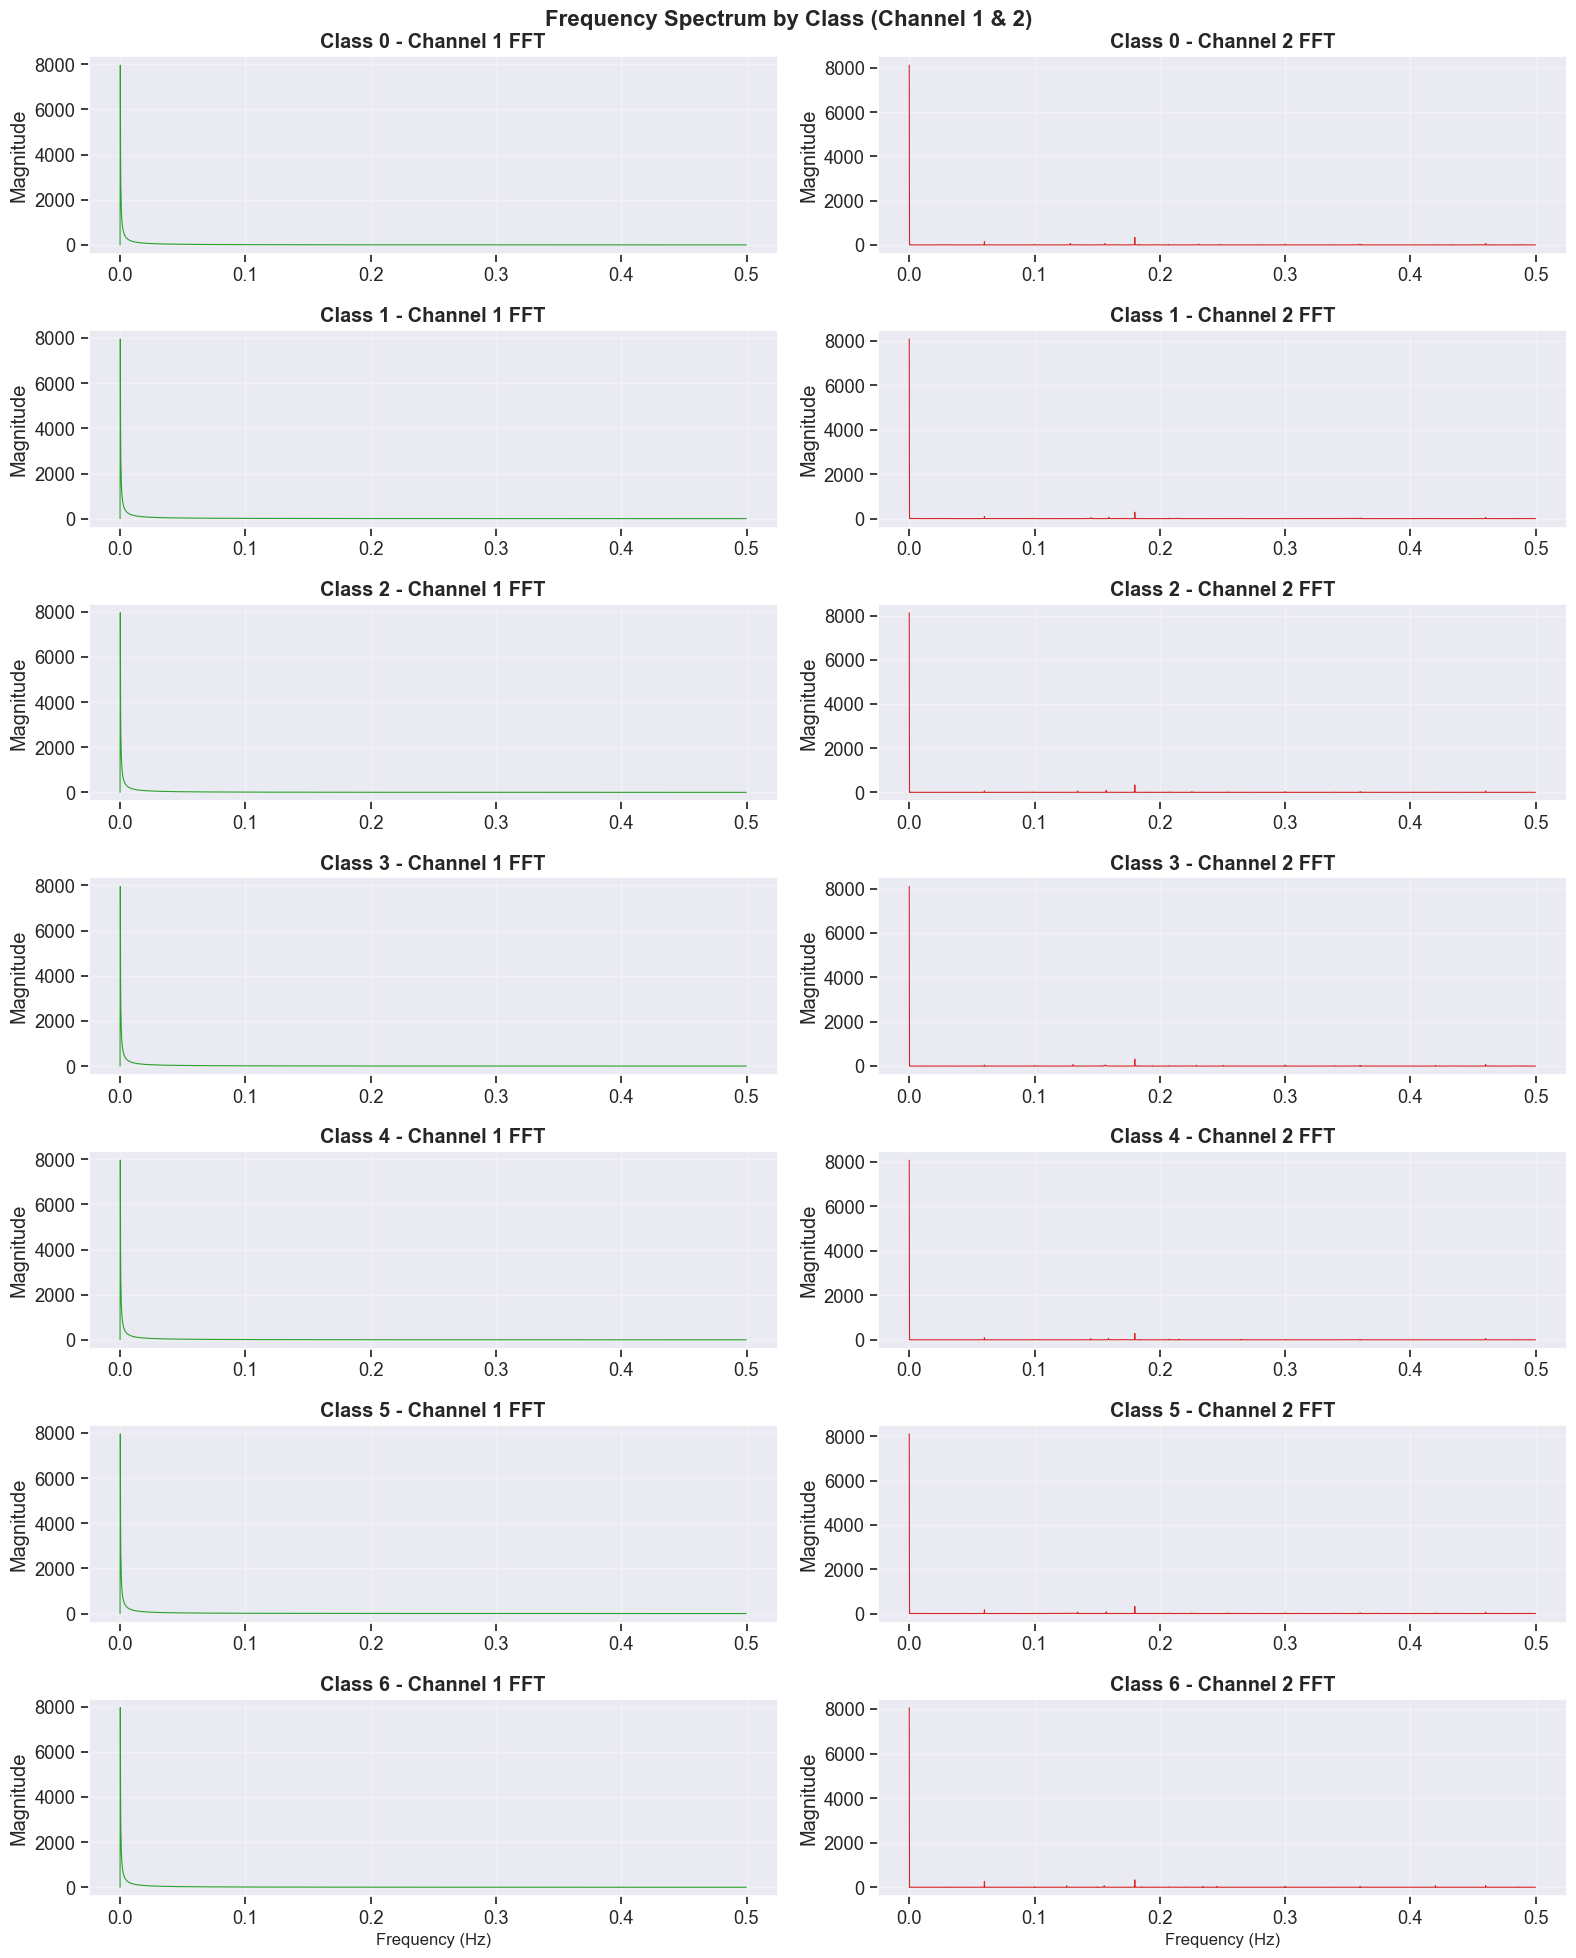

In [4]:
### Frequency Domain Analysis
from scipy.fft import fft, fftfreq

fig, axes = plt.subplots(7, 2, figsize=(16, 20))
fig.suptitle('Frequency Spectrum by Class (Channel 1 & 2)', fontsize=16, fontweight='bold')

for class_idx in range(7):
    class_samples = np.where(y == class_idx)[0]
    if len(class_samples) > 0:
        sample_idx = class_samples[0]
        signal = X[sample_idx]
        
        # FFT for Channel 1
        fft_vals = np.abs(fft(signal[:, 0]))
        freqs = fftfreq(len(signal[:, 0]), 1.0)
        axes[class_idx, 0].plot(freqs[:len(freqs)//2], fft_vals[:len(fft_vals)//2], linewidth=0.8, color='#2ca02c')
        axes[class_idx, 0].set_title(f'Class {class_idx} - Channel 1 FFT', fontweight='bold')
        axes[class_idx, 0].set_ylabel('Magnitude')
        axes[class_idx, 0].grid(alpha=0.3)
        
        # FFT for Channel 2
        fft_vals = np.abs(fft(signal[:, 1]))
        axes[class_idx, 1].plot(freqs[:len(freqs)//2], fft_vals[:len(fft_vals)//2], linewidth=0.8, color='#d62728')
        axes[class_idx, 1].set_title(f'Class {class_idx} - Channel 2 FFT', fontweight='bold')
        axes[class_idx, 1].set_ylabel('Magnitude')
        axes[class_idx, 1].grid(alpha=0.3)

axes[-1, 0].set_xlabel('Frequency (Hz)', fontsize=12)
axes[-1, 1].set_xlabel('Frequency (Hz)', fontsize=12)
plt.tight_layout()
plt.show()


### 2.1 Data Reshaping and Normalization
CNNs and LSTMs expect 3D input. Our data is likely 2D `(samples, time_points)`. We'll reshape it to `(samples, time_points, 1)`.

In [5]:
if 'X' in locals():
    # Reshape for DL: (samples, time_steps, 1)
    if X.ndim == 2:

    # FIX: Scale data for better convergence
     print("Scaling data...")
    # Reshape to 2D for scaling: (samples, time_steps * channels)
    # But wait, X is currently (samples, time_steps, channels) or (samples, time_steps)
    # Let's handle the scaling carefully.
    
    # 1. Flatten for scaling
    orig_shape = X.shape
    if X.ndim == 3:
        X_flat = X.reshape(orig_shape[0], -1)
    else:
        X_flat = X
        
    # 2. Scale

    # FIX: Handle NaN and Infinity values before scaling
    print("Checking for NaN or Infinity values...")
    # Check if X_flat is a DataFrame or numpy array
    if hasattr(X_flat, 'replace'): # DataFrame
        X_flat.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_flat.fillna(X_flat.mean(), inplace=True)
    else: # Numpy array
        X_flat = np.nan_to_num(X_flat, nan=0.0, posinf=0.0, neginf=0.0)
    print("Data cleaned (NaN/Inf removed).")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flat)
    
    # 3. Reshape back
    if len(orig_shape) == 3:
        X = X_scaled.reshape(orig_shape)
    else:
        X = X_scaled
    
    print("Data scaled.")
    
    # X = X.reshape(X.shape[0], X.shape[1], 1) # REMOVED: Data already has correct shape from scaling
    
    print(f"New Data Shape: {X.shape}")
    
    # Encode Labels
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)
    y_categorical = to_categorical(y_encoded)
    
    print(f"Classes: {encoder.classes_}")
    
    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)
    
    print(f"Train Shape: {X_train.shape}")
    print(f"Test Shape: {X_test.shape}")

Checking for NaN or Infinity values...
Data cleaned (NaN/Inf removed).
Data scaled.
New Data Shape: (2617, 5000, 2)
Classes: [0 1 2 3 4 5 6]
Train Shape: (2093, 5000, 2)
Test Shape: (524, 5000, 2)



CLASS DISTRIBUTION ANALYSIS
Detected one-hot encoded labels. Converting to indices for counting...

Training Set Distribution:
  Class 0 (Class 0): 284 samples (13.6%)
  Class 1 (Class 1): 302 samples (14.4%)
  Class 2 (Class 2): 301 samples (14.4%)
  Class 3 (Class 3): 313 samples (15.0%)
  Class 4 (Class 4): 303 samples (14.5%)
  Class 5 (Class 5): 297 samples (14.2%)
  Class 6 (Class 6): 293 samples (14.0%)

Test Set Distribution:
  Class 0 (Class 0): 69 samples (13.2%)
  Class 1 (Class 1): 80 samples (15.3%)
  Class 2 (Class 2): 78 samples (14.9%)
  Class 3 (Class 3): 74 samples (14.1%)
  Class 4 (Class 4): 74 samples (14.1%)
  Class 5 (Class 5): 78 samples (14.9%)
  Class 6 (Class 6): 71 samples (13.5%)


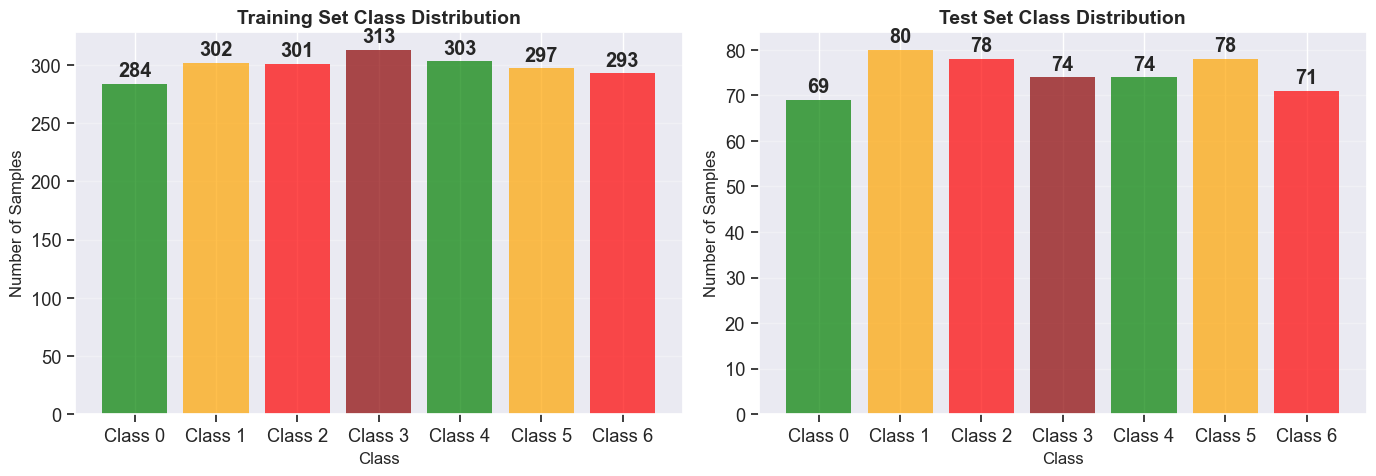


Imbalance Ratio: 1.10:1
Classes are relatively balanced.


In [6]:
# ===== DATA BALANCE ANALYSIS =====
from collections import Counter

print("\n" + "="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)

# Class names
class_names = [f'Class {i}' for i in range(7)] # Updated to match 7 unique labels in data

# Count classes
# Handle one-hot encoding (if present)
if hasattr(y_train, 'ndim') and y_train.ndim > 1 and y_train.shape[1] > 1:
    print("Detected one-hot encoded labels. Converting to indices for counting...")
    y_train_indices = np.argmax(y_train, axis=1)
    y_test_indices = np.argmax(y_test, axis=1)
else:
    y_train_indices = y_train
    y_test_indices = y_test

# Count classes
train_counts = Counter(y_train_indices)
test_counts = Counter(y_test_indices)

print("\nTraining Set Distribution:")
for cls in sorted(train_counts.keys()):
    print(f"  Class {cls} ({class_names[cls]}): {train_counts[cls]} samples ({train_counts[cls]/len(y_train)*100:.1f}%)")

print("\nTest Set Distribution:")
for cls in sorted(test_counts.keys()):
    print(f"  Class {cls} ({class_names[cls]}): {test_counts[cls]} samples ({test_counts[cls]/len(y_test)*100:.1f}%)")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_labels = [class_names[i] for i in sorted(train_counts.keys())]
train_values = [train_counts[i] for i in sorted(train_counts.keys())]
axes[0].bar(train_labels, train_values, color=['green', 'orange', 'red', 'darkred'], alpha=0.7)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_values):
    axes[0].text(i, v + max(train_values)*0.02, str(v), ha='center', fontweight='bold')

# Test set
test_labels = [class_names[i] for i in sorted(test_counts.keys())]
test_values = [test_counts[i] for i in sorted(test_counts.keys())]
axes[1].bar(test_labels, test_values, color=['green', 'orange', 'red', 'darkred'], alpha=0.7)
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_values):
    axes[1].text(i, v + max(test_values)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Check for imbalance
max_count = max(train_counts.values())
min_count = min(train_counts.values())
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("WARNING: Significant class imbalance detected!")
    print("   Consider using class weights in model.fit() or SMOTE.")
else:
    print("Classes are relatively balanced.")


## 3. Model Building

### 3.1 1D CNN Model
CNNs are excellent at capturing local patterns (features) in time-series data.

In [7]:
def build_cnn_model(input_shape, num_classes):
    """Improved CNN model with deeper architecture for better accuracy."""
    model = Sequential([
        # First Conv Block
        Conv1D(filters=64, kernel_size=5, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Second Conv Block
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Third Conv Block
        Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Global pooling and classification
        tf.keras.layers.GlobalAveragePooling1D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    # Use Adam with learning rate schedule
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

input_shape = (X_train.shape[1], X_train.shape[2]) # Fixed: Use actual number of channels from data
num_classes = y_categorical.shape[1]

cnn_model = build_cnn_model(input_shape, num_classes)
cnn_model.summary()


C:\Users\WORKNFLOW\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5000, 64)       │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5000, 64)       │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2500, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2500, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2500, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2500, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2500, 128)      │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1250, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1250, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1250, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1250, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 625, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 625, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,199 (1.13 MB)

 Trainable params: 294,791 (1.12 MB)

 Non-trainable params: 1,408 (5.50 KB)

### 3.2 LSTM Model
LSTMs are designed to remember long-term dependencies, making them suitable for sequential data.

In [8]:
def build_lstm_model(input_shape, num_classes):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(100, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm_model(input_shape, num_classes)
lstm_model.summary()

C:\Users\WORKNFLOW\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5000, 64)       │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           707 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,575 (131.15 KB)

 Trainable params: 33,575 (131.15 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training
We will train the CNN model first as it is generally faster and highly effective for vibration data.

In [9]:
# Train CNN with improved configuration
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for better training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=50,  # Increased from 20
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.3901 - loss: 1.6327 - val_accuracy: 0.1456 - val_loss: 1.9587 - learning_rate: 0.0010
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.4815 - loss: 1.2784 - val_accuracy: 0.1456 - val_loss: 2.2060 - learning_rate: 0.0010
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5311 - loss: 1.1122 - val_accuracy: 0.1790 - val_loss: 2.6904 - learning_rate: 0.0010
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.5514 - loss: 1.0525 - val_accuracy: 0.1432 - val_loss: 4.7378 - learning_rate: 0.0010
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6237 - loss: 0.9559 - val_accuracy: 0.1885 - val_loss: 3.5209 - learning_rate: 0.0010
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6124 - loss: 0.9179
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
53/53 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6470 - loss: 0.8682 - val_accura

17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 466ms/step


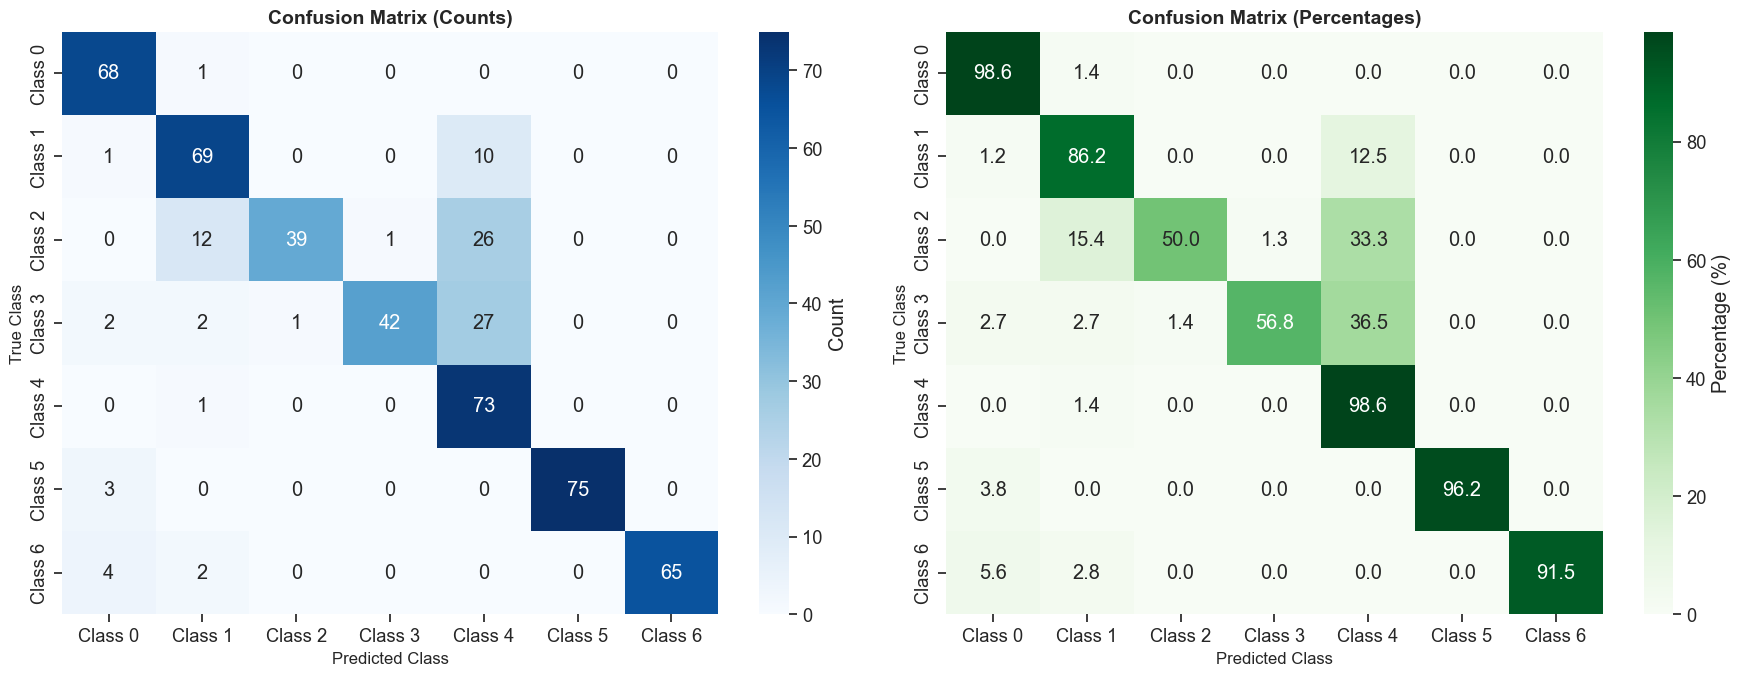


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.87      0.99      0.93        69
     Class 1       0.79      0.86      0.83        80
     Class 2       0.97      0.50      0.66        78
     Class 3       0.98      0.57      0.72        74
     Class 4       0.54      0.99      0.70        74
     Class 5       1.00      0.96      0.98        78
     Class 6       1.00      0.92      0.96        71

    accuracy                           0.82       524
   macro avg       0.88      0.83      0.82       524
weighted avg       0.88      0.82      0.82       524



In [10]:
### Enhanced Confusion Matrix with Percentages
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Class', fontsize=12)
ax1.set_ylabel('True Class', fontsize=12)
ax1.set_xticklabels([f'Class {i}' for i in range(7)])
ax1.set_yticklabels([f'Class {i}' for i in range(7)])

# Percentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', ax=ax2, cbar_kws={'label': 'Percentage (%)'})
ax2.set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=12)
ax2.set_ylabel('True Class', fontsize=12)
ax2.set_xticklabels([f'Class {i}' for i in range(7)])
ax2.set_yticklabels([f'Class {i}' for i in range(7)])

plt.tight_layout()
plt.show()

# Print classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_classes, y_pred_classes, target_names=[f'Class {i}' for i in range(7)]))


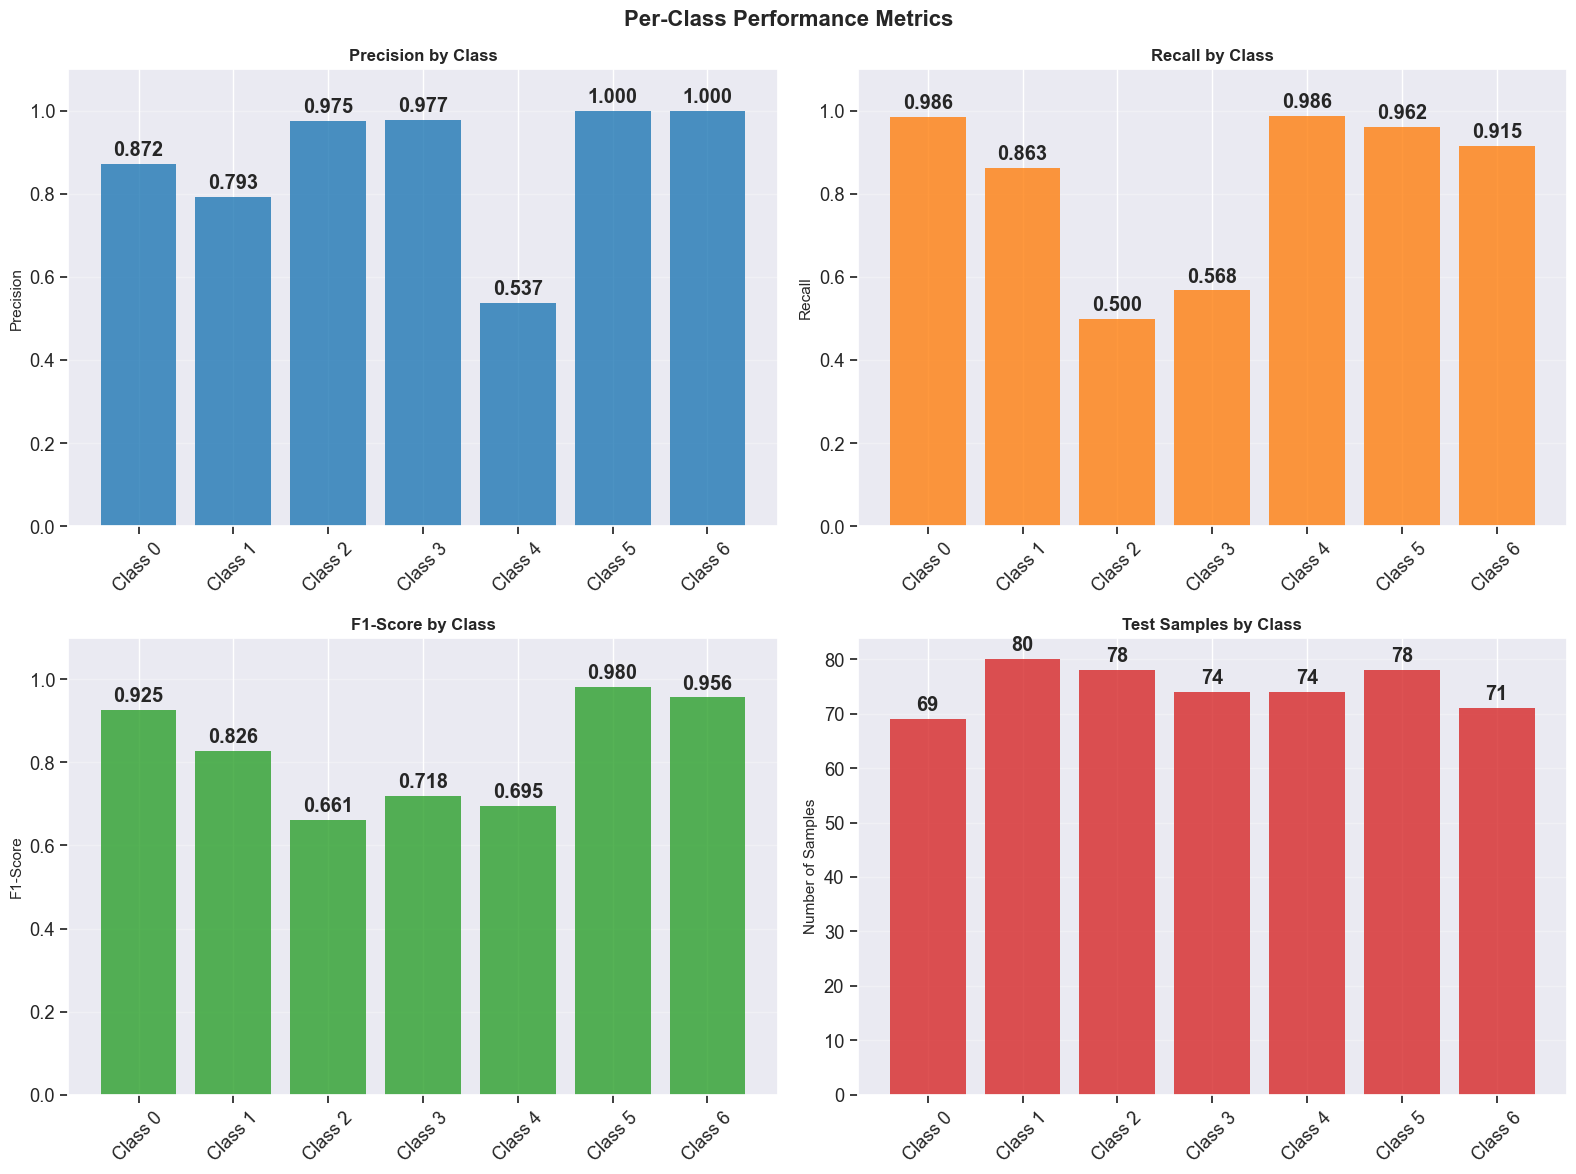

In [11]:
### Per-Class Performance Metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test_classes, y_pred_classes)

# Create bar plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Per-Class Performance Metrics', fontsize=16, fontweight='bold')

classes = [f'Class {i}' for i in range(7)]
x = np.arange(len(classes))

# Precision
axes[0, 0].bar(x, precision, color='#1f77b4', alpha=0.8)
axes[0, 0].set_title('Precision by Class', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Precision', fontsize=11)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(classes, rotation=45)
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(precision):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Recall
axes[0, 1].bar(x, recall, color='#ff7f0e', alpha=0.8)
axes[0, 1].set_title('Recall by Class', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Recall', fontsize=11)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(classes, rotation=45)
axes[0, 1].set_ylim([0, 1.1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(recall):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score
axes[1, 0].bar(x, f1, color='#2ca02c', alpha=0.8)
axes[1, 0].set_title('F1-Score by Class', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('F1-Score', fontsize=11)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(classes, rotation=45)
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Support (sample count)
axes[1, 1].bar(x, support, color='#d62728', alpha=0.8)
axes[1, 1].set_title('Test Samples by Class', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Number of Samples', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(classes, rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(support):
    axes[1, 1].text(i, v + max(support)*0.02, f'{int(v)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


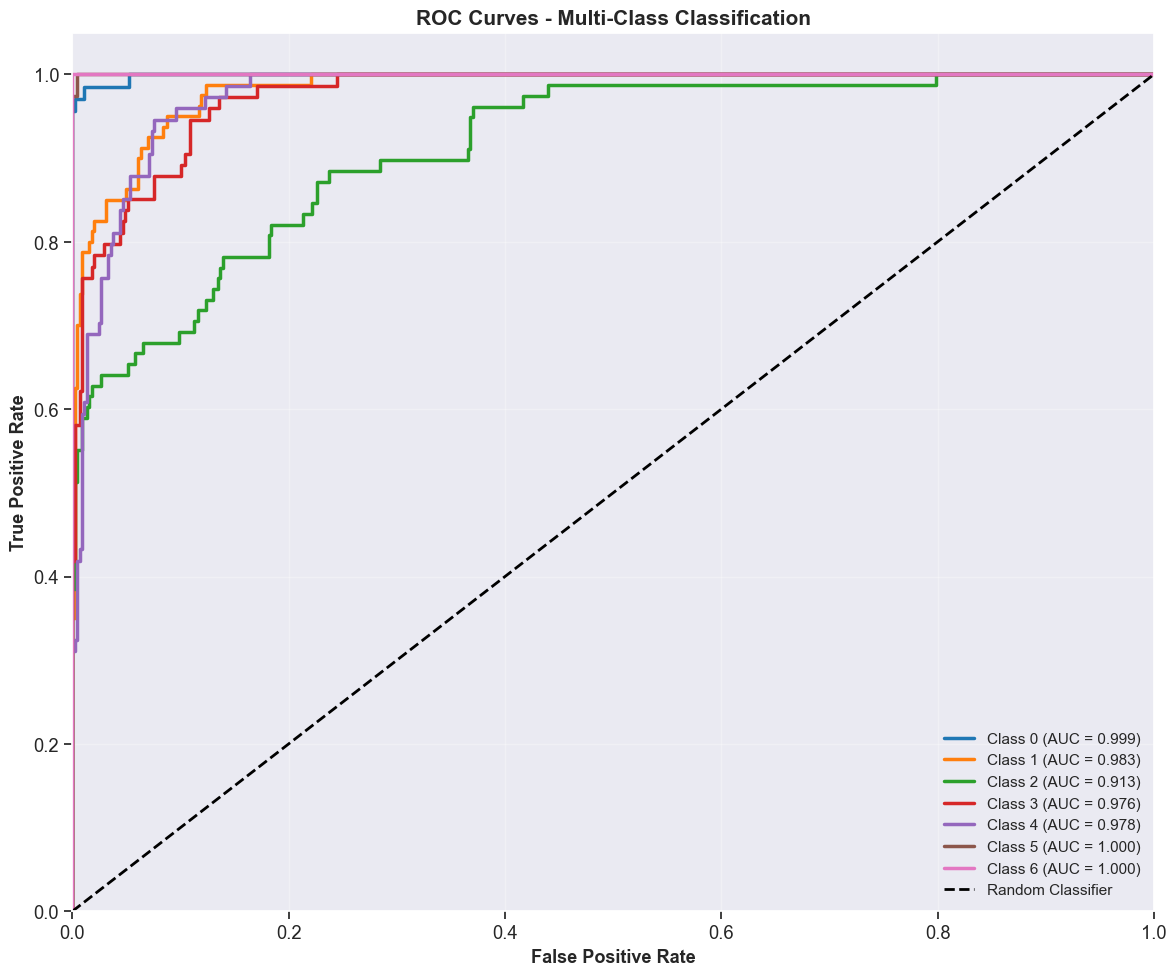


AUC SCORES BY CLASS
Class 0: 0.9990
Class 1: 0.9829
Class 2: 0.9134
Class 3: 0.9763
Class 4: 0.9778
Class 5: 0.9999
Class 6: 1.0000

Mean AUC: 0.9785


In [12]:
### ROC Curves for Multi-Class Classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize for ROC
y_test_bin = label_binarize(y_test_classes, classes=range(7))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(12, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, color in zip(range(7), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Multi-Class Classification', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC scores
print("\n" + "="*60)
print("AUC SCORES BY CLASS")
print("="*60)
for i in range(7):
    print(f"Class {i}: {roc_auc[i]:.4f}")
print(f"\nMean AUC: {np.mean(list(roc_auc.values())):.4f}")


## 5. Evaluation and Visualization
We will plot the training curves and the confusion matrix.

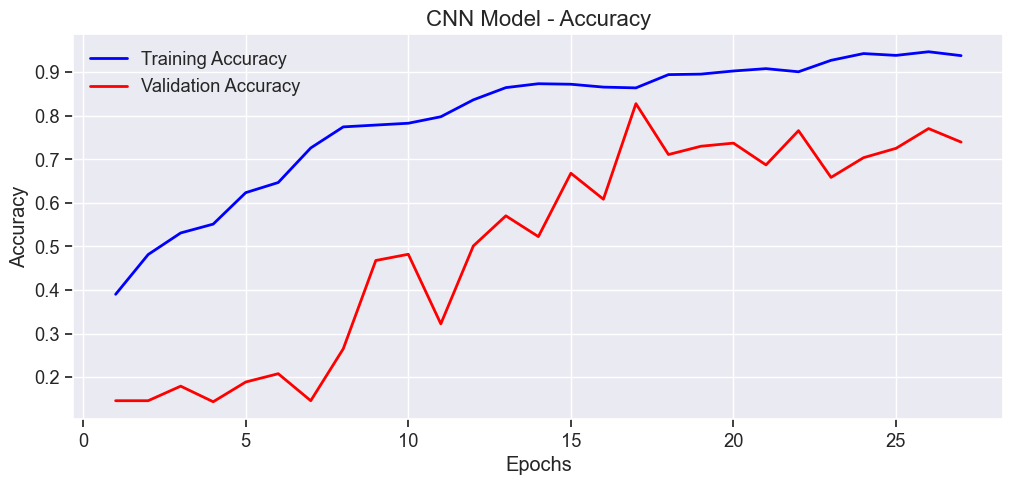

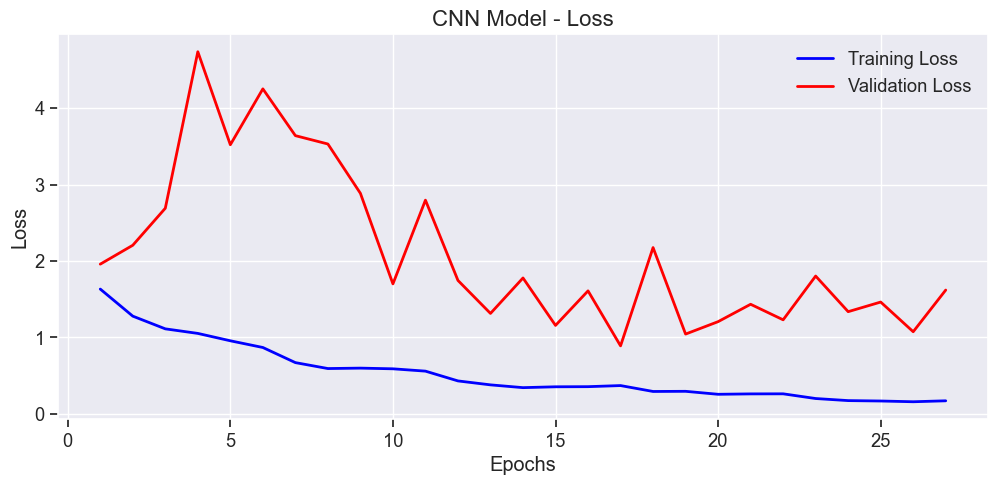

In [13]:
def plot_training_history(history, title):
    """Plots accuracy and loss curves."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    
    # Accuracy Plot
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f"{title} - Accuracy", fontsize=16)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
    
    # Loss Plot
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f"{title} - Loss", fontsize=16)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training_history(history_cnn, "CNN Model")

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step


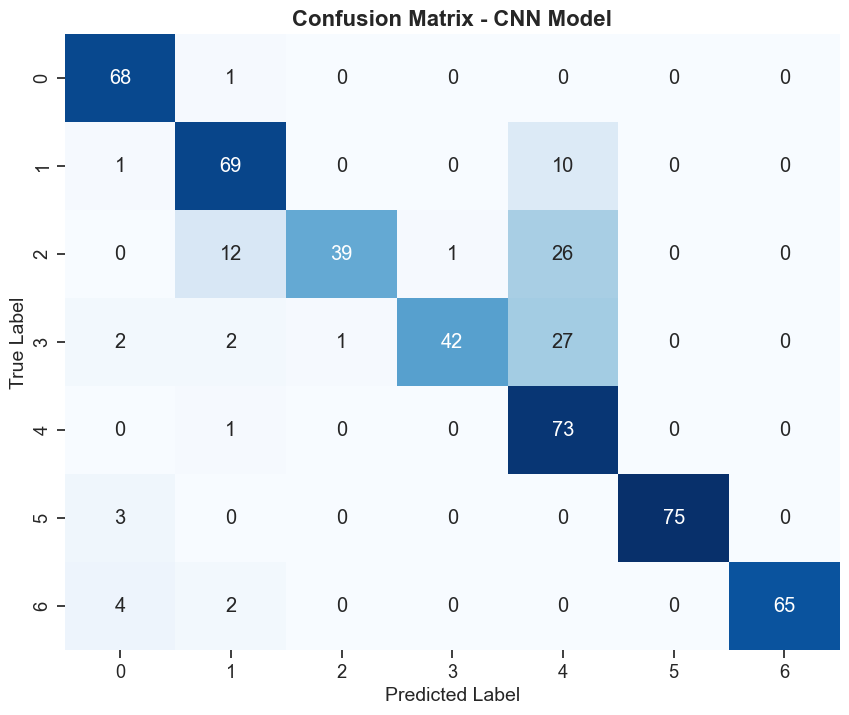

In [14]:
# Confusion Matrix
y_pred_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix - CNN Model", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

In [15]:
# Save Model
save_dir = "../Trained_models/Induction_Motor_DL"
os.makedirs(save_dir, exist_ok=True)
cnn_model.save(os.path.join(save_dir, "cnn_model.h5"))
print("Model saved successfully.")

Model saved successfully.
